In [12]:
import uproot
import pandas as pd
import awkward as ak
import matplotlib.pyplot as plt

tables = [
    "O2upgradecascades",
    "O2upgradev0s"
]

def load_tables(filename, tables):
    data_dict = {}

    with uproot.open(filename) as f:
        keys = f.keys()
        print(f"Keys in {filename}: {keys}")

        for table in tables:
            matched_keys = [
                key for key in keys
                if len(key.split("/")) == 2
                and key.split("/")[1].split(";")[0] == table
            ]
            # matched_keys = [key for key in keys if table == key.split("/")[1].replace(";1", "") and len(key.split("/")) == 2]
            # matched_keys = [key for key in keys if table in key]

            if not matched_keys:
                print(f"No keys found for table: {table}")
                continue

            table_dfs = []

            for key in matched_keys:
                array = f[key].arrays(library="ak")

                if len(array) == 0:
                    print(f"Empty array for key: {key}")
                    continue

                data = {}
                for k in array.fields:
                    v = array[k]
                    
                    if isinstance(ak.type(v).content, ak.types.NumpyType):
                        # scalar branch
                        data[k] = ak.to_numpy(v)
                    else:
                        # vector branch
                        data[k] = ak.to_list(v)

                df = pd.DataFrame(data)

                if df.empty:
                    print(f"Empty DataFrame for key: {key}")
                    continue

                # optional but VERY useful: avoid duplicate column collisions
                df = df.add_prefix(f"{table}__")

                table_dfs.append(df)

            if table_dfs:
                data_dict[table] = pd.concat(table_dfs, ignore_index=True)
            else:
                print(f"No usable data for table: {table}")

    return data_dict

# Load datasets
df_after_mod  = load_tables("TreeRecoAfter.root", tables)

Keys in TreeRecoAfter.root: ['DF_1;1', 'DF_1/O2upgradecascades;1', 'DF_1/O2upgradev0s;1', 'parentFiles;1']


In [13]:
# Compare lengths of tables
for table in tables:
    len_after = len(df_after_mod.get(table, []))
    print(f"Table: {table}, After Modifications: {len_after} entries")

Table: O2upgradecascades, After Modifications: 29677 entries
Table: O2upgradev0s, After Modifications: 154121 entries


In [14]:
print("Data loaded successfully.")
print(f"keys df_after_mod: {df_after_mod.keys()}")

Data loaded successfully.
keys df_after_mod: dict_keys(['O2upgradecascades', 'O2upgradev0s'])


In [15]:
df_after_mod["O2upgradecascades"][0:10]

,O2upgradecascades__fIndexCollisions,O2upgradecascades__fIndexTracks_Cascade,O2upgradecascades__fIndexTracks_Pos,O2upgradecascades__fIndexTracks_Neg,O2upgradecascades__fIndexTracks_Bach,O2upgradecascades__fDcaV0Daughters,O2upgradecascades__fDcaCascadeDaughters,O2upgradecascades__fV0Radius,O2upgradecascades__fCascRadius,O2upgradecascades__fCascRadiusMC,O2upgradecascades__fMLambda,O2upgradecascades__fMXi,O2upgradecascades__fFindableClusters,O2upgradecascades__fFoundClusters
0,6,113,112,111,110,0.001605,0.002962,4.052349,0.873720,0.869465,1.115880,1.321763,1,1
1,9,193,192,191,190,0.000071,0.000525,11.396314,5.018342,5.013505,1.116403,1.321737,3,3
2,15,259,258,257,256,0.000837,0.003127,10.622371,1.223209,1.157373,1.113439,1.323569,1,1
3,23,462,461,460,459,0.006166,0.005671,11.129199,7.594323,7.563704,1.119422,1.320357,4,4
4,24,474,473,472,471,0.037222,0.008941,3.762617,0.599682,0.619580,1.113217,1.320950,1,1
5,25,488,487,486,485,0.000847,0.018632,7.333627,4.160110,4.218206,1.115023,1.316612,3,3
6,28,519,518,517,516,0.000999,0.003241,1.954782,1.380646,1.384750,1.114719,1.320732,2,2
7,32,616,615,614,613,0.003029,0.000520,7.715269,6.601946,6.600229,1.115319,1.322638,3,3
8,37,695,694,693,692,0.000005,0.001109,7.426213,1.537258,1.527150,1.116513,1.319030,2,2
9,55,1275,1274,1273,1272,0.001052,0.006320,7.888014,2.527647,2.534929,1.115117,1.322841,3,3


In [16]:
df_after_mod["O2upgradev0s"][0:10]

,O2upgradev0s__fIndexCollisions,O2upgradev0s__fIndexV0s,O2upgradev0s__fIndexTracks_Pos,O2upgradev0s__fIndexTracks_Neg,O2upgradev0s__fDcaV0Daughters,O2upgradev0s__fV0Radius,O2upgradev0s__fMLambda,O2upgradev0s__fMAntiLambda,O2upgradev0s__fMK0,O2upgradev0s__fPt
0,0,45,1,0,0.029798,4.427201,-1.0,-1.000000,0.494753,1.114730
1,0,52,3,2,0.001831,1.711301,-1.0,-1.000000,0.494446,1.352508
2,1,140,46,45,0.003243,11.144876,-1.0,1.117233,-1.000000,1.229160
3,5,265,92,91,0.027639,1.677423,-1.0,-1.000000,0.511500,0.260066
4,5,266,94,93,0.016212,3.035650,-1.0,-1.000000,0.497384,0.475398
5,5,268,96,95,0.001515,2.927586,-1.0,-1.000000,0.497286,0.471893
6,10,552,205,204,0.001792,3.137796,-1.0,-1.000000,0.497224,0.905741
7,13,587,224,223,0.003430,2.099314,-1.0,-1.000000,0.496600,0.386805
8,15,699,261,260,0.015127,1.815428,-1.0,1.116726,-1.000000,1.512841
9,16,782,285,284,0.013094,4.898095,-1.0,-1.000000,0.498745,0.710984


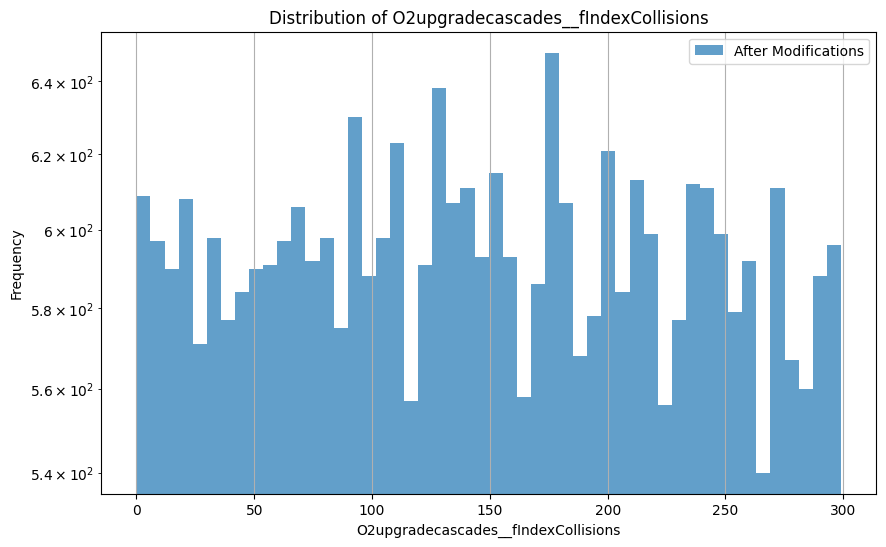

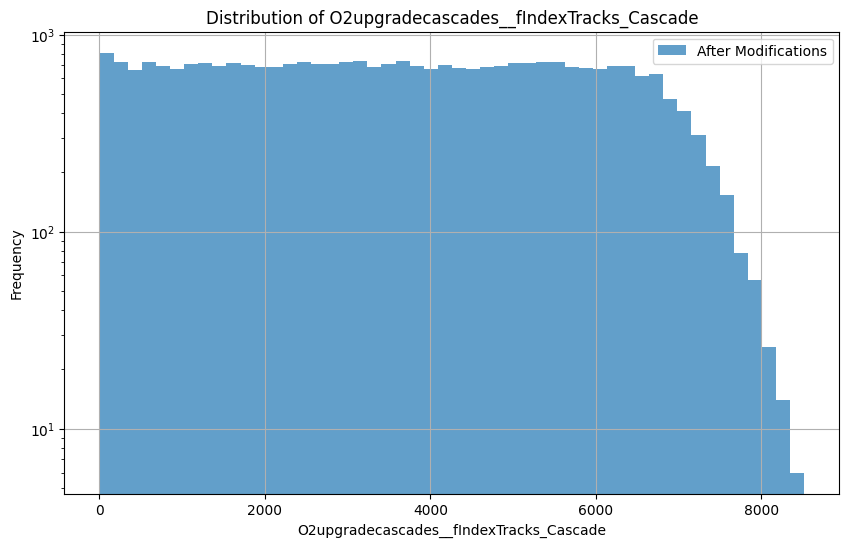

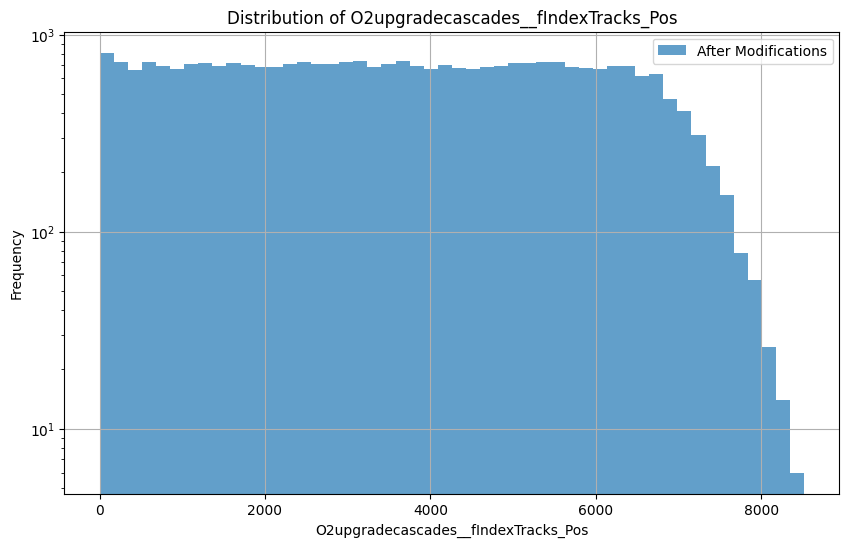

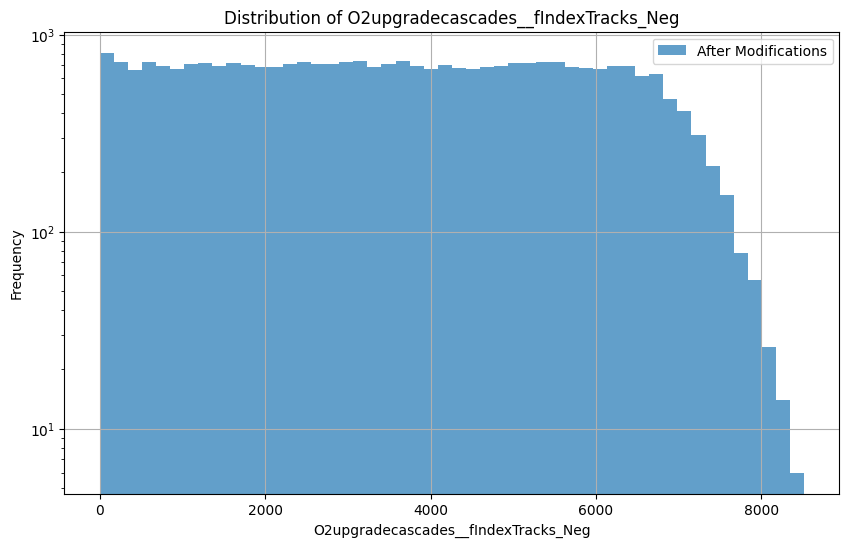

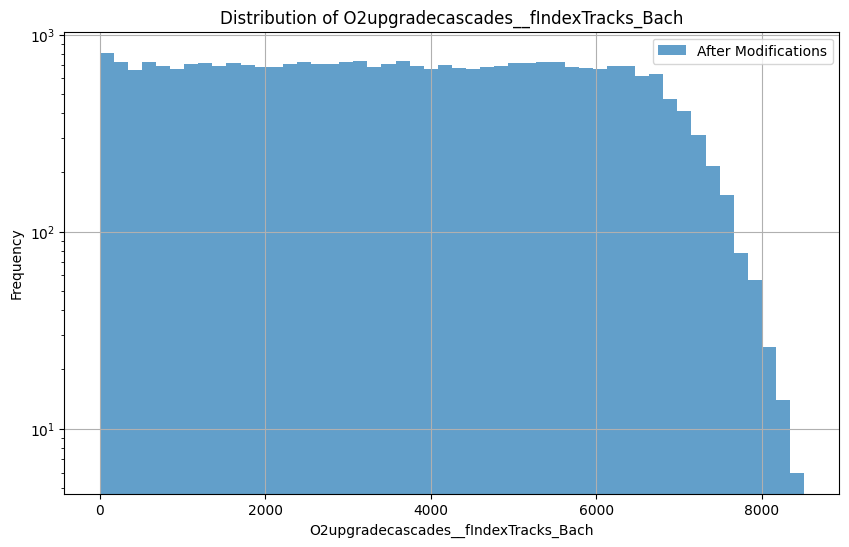

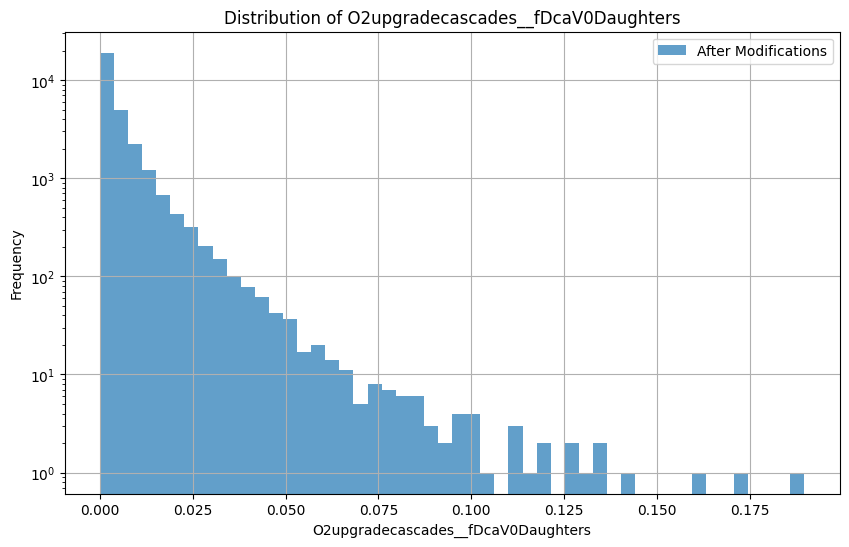

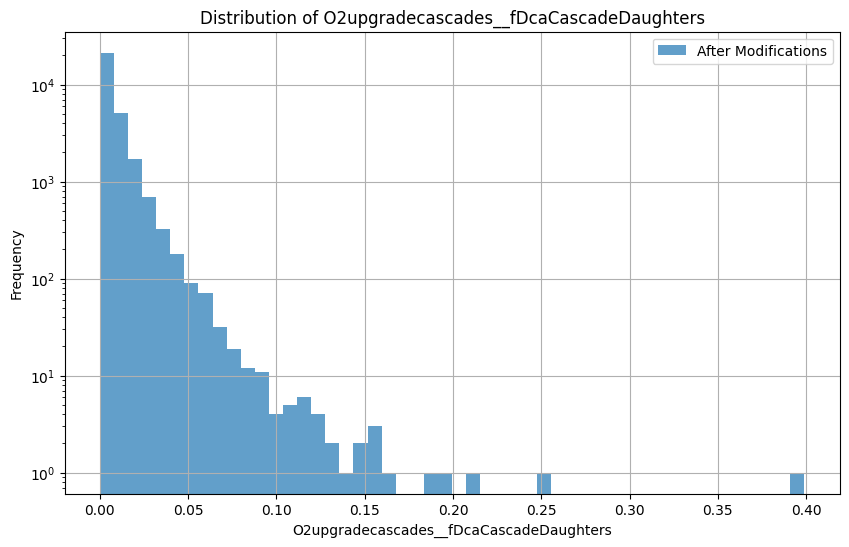

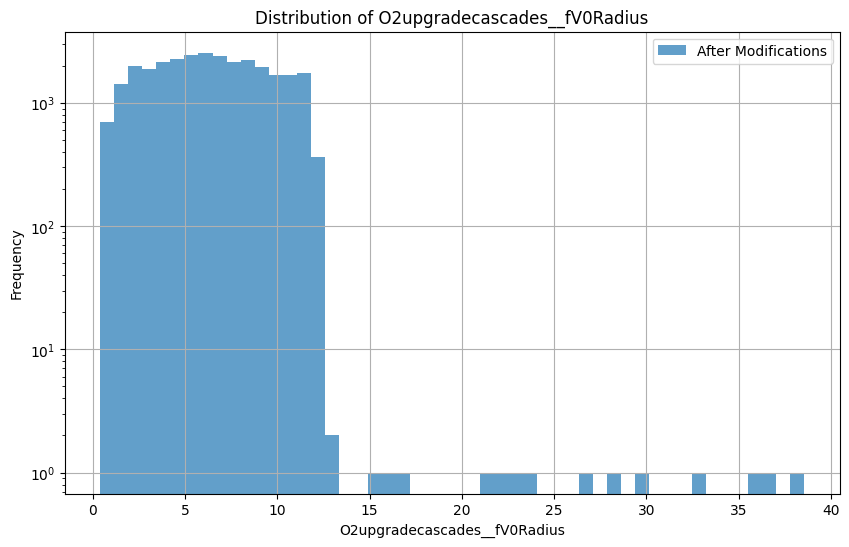

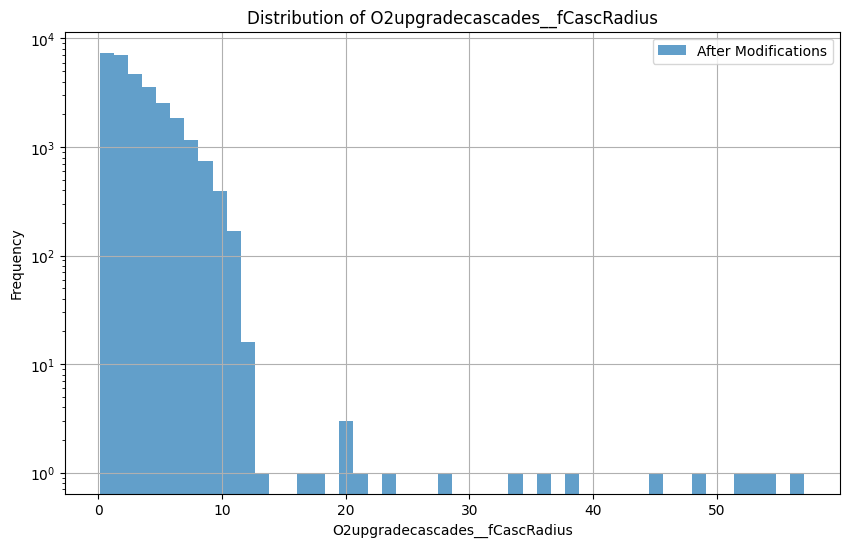

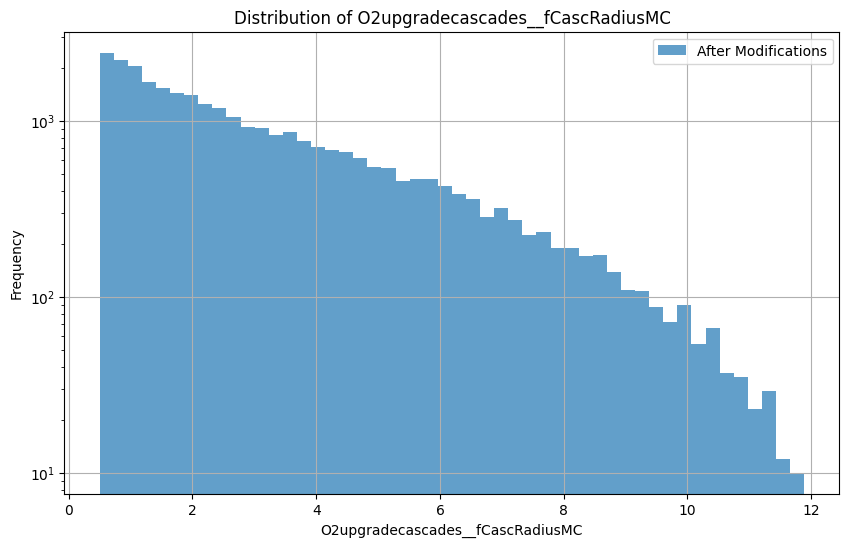

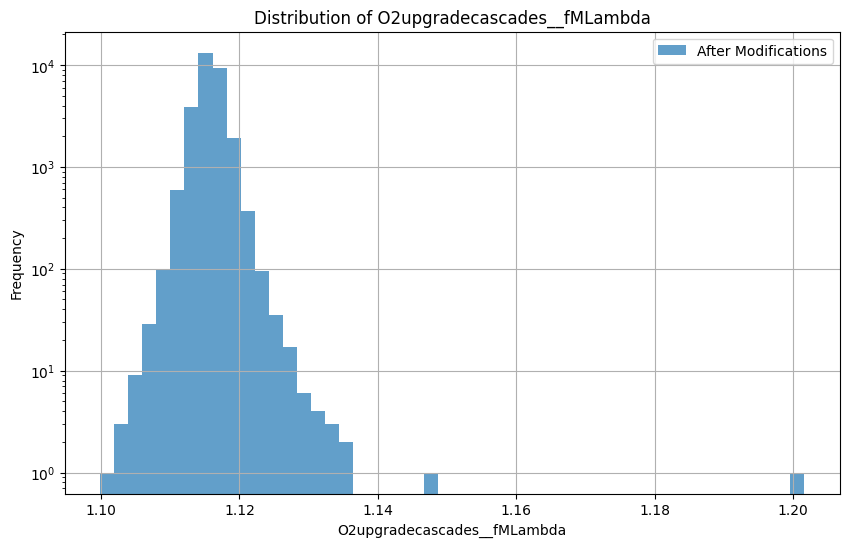

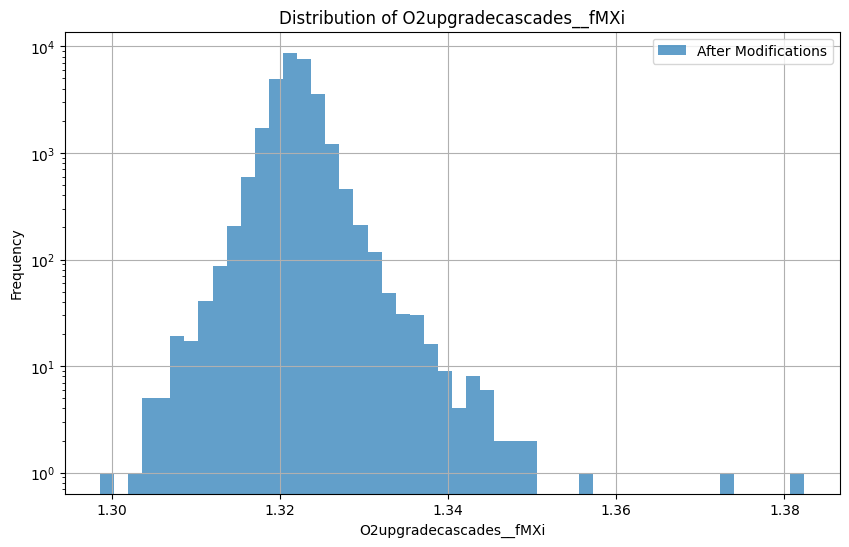

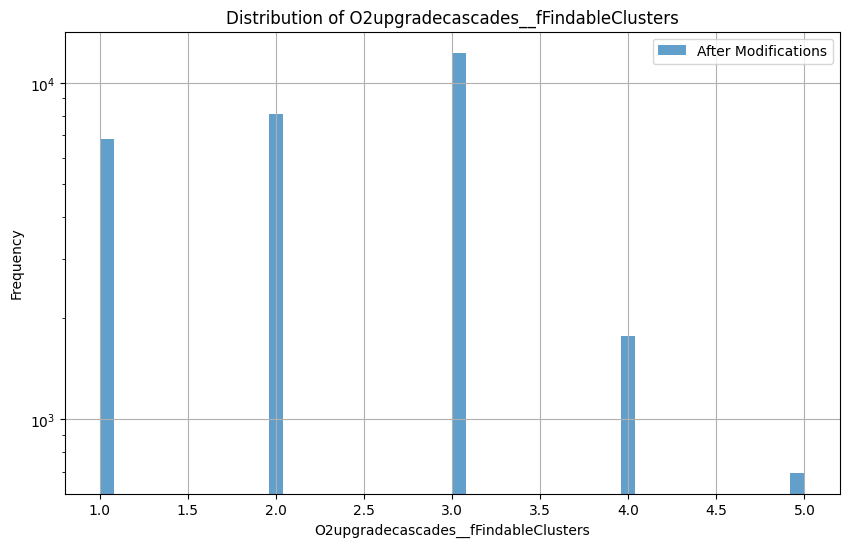

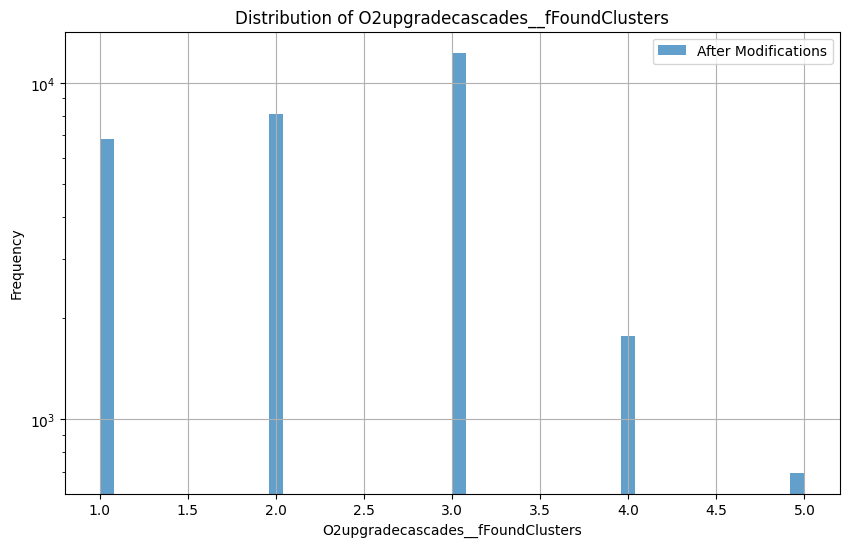

In [17]:
# Plot all columns of the cascades table
for column in df_after_mod["O2upgradecascades"].columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_after_mod["O2upgradecascades"][column], bins=50, range=(df_after_mod["O2upgradecascades"][column].min(), df_after_mod["O2upgradecascades"][column].max()), alpha=0.7, log=True, label='After Modifications')
    # plt.hist(df_before_mod["O2upgradecascades"][column], bins=50, range=(df_after_mod["O2upgradecascades"][column].min(), df_after_mod["O2upgradecascades"][column].max()), alpha=0.7, log=True, label='Before Modifications')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()

NameError: name 'df_before_mod' is not defined

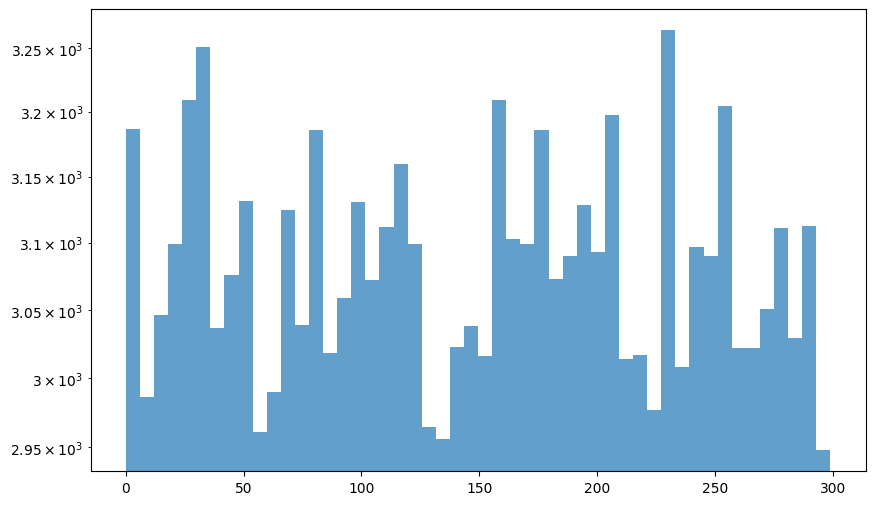

In [18]:
# Plot all columns of the cascades table
for column in df_after_mod["O2upgradev0s"].columns:
    plt.figure(figsize=(10, 6))
    plt.hist(df_after_mod["O2upgradev0s"][column], bins=50, alpha=0.7, log=True, label='After Modifications')
    plt.hist(df_before_mod["O2upgradev0s"][column], bins=50, alpha=0.7, log=True, label='Before Modifications')
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid()
    plt.show()